In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
from datetime import datetime

In [3]:
file_path = '/content/UST Data Sample (July - Sept 2024).xlsx'
df = pd.read_excel(file_path)
df

,let me tak,Id,Client,RFQStatus,InstrumentSubGroup,Market Traded Vol (USD),Our Traded Vol,TiedWonVol,Num of Dealers,Trader,...,SettlementDays,SettlementDate,SettlementStops,RFQ CreateTime,RFQ ClosedTime,AnAutoReplyRFQs,First Response Time (Sec),TradeSizeBucket,Sector,MaturityBucket
0,2024-09-30,66FA7D45432800D20002,Client1,Done,OFFTHERUN,100000000,100000000,100000000,6,Trader1,...,1,2024-10-01,T+1,2024-09-30 06:28:00,2024-09-30 06:28:00,1,0.03,50+M,5-7 YR,5y-7y
1,2024-09-30,TRSY_20240930_15961,Client2,Done,"OFFTHERUN,DOUBLEOLDS",2100000,2100000,2100000,5,Trader2,...,1,2024-10-01,T+1,2024-09-30 16:00:00,2024-09-30 16:00:00,1,0.95,1-5M,7-10 YR,7y-10y
2,2024-09-30,TRSY_20240930_314,Client2,Done,ONTHERUN,53000000,53000000,53000000,5,Trader3,...,1,2024-10-01,T+1,2024-09-30 15:46:00,2024-09-30 15:46:00,1,0.07,50+M,7-10 YR,7y-10y
3,2024-09-30,66FAEA57432800020001,Client3,Done,OFFTHERUN,500000,500000,500000,5,Trader4,...,1,2024-10-01,T+1,2024-09-30 14:14:00,2024-09-30 14:14:00,1,0.03,500K-1M,0-1 YR,<18mos
4,2024-09-30,66FAC35D455C00210006,Client4,Done,OFFTHERUN,1058000,1058000,1058000,5,Trader2,...,1,2024-10-01,T+1,2024-09-30 11:27:00,2024-09-30 11:27:00,1,0.03,1-5M,5-7 YR,3y-5y
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66676,2024-07-01,E68302E5454C00010001,Client33,CustomerTimeOut,ONTHERUN,0,0,0,1,Trader4,...,1,2024-07-02,T+1,2024-07-01 15:26:00,2024-07-01 15:27:00,1,0.04,1-5M,BILLS,<18mos
66677,2024-07-01,E68305CA57D000080001,Client33,CustomerTimeOut,ONTHERUN,0,0,0,1,Trader4,...,1,2024-07-02,T+1,2024-07-01 15:38:00,2024-07-01 15:40:00,1,0.04,1-5M,BILLS,<18mos
66678,2024-07-01,E683099657D000010001,Client33,CustomerTimeOut,ONTHERUN,0,0,0,1,Trader4,...,1,2024-07-02,T+1,2024-07-01 15:55:00,2024-07-01 15:56:00,1,0.04,1-5M,BILLS,<18mos
66679,2024-07-01,6682BE1857D0000C0002,Client271,CustomerTimeOut,OFFTHERUN,0,0,0,15,Trader4,...,1,2024-07-02,T+1,2024-07-01 10:33:00,2024-07-01 10:34:00,0,4.99,10-25M,0-1 YR,<18mos


In [4]:
df = df[::-1]
df = df.reset_index(drop=True)

In [5]:
missing_values = df.isnull().sum()
missing_values[:20]

,0
let me tak,0
Id,0
Client,0
RFQStatus,0
InstrumentSubGroup,0
Market Traded Vol (USD),0
Our Traded Vol,0
TiedWonVol,0
Num of Dealers,0
Trader,0


In [6]:
missing_values[20:]

,0
RFQNumberOfQuotes,0
Buy/Sell,0
Best Bid Price,0
Mid Price,0
Best Ask Price,0
Deal Value,0
AwayFromMid,0
TickIdentifier,445
Deal Spread,0
Cover,0


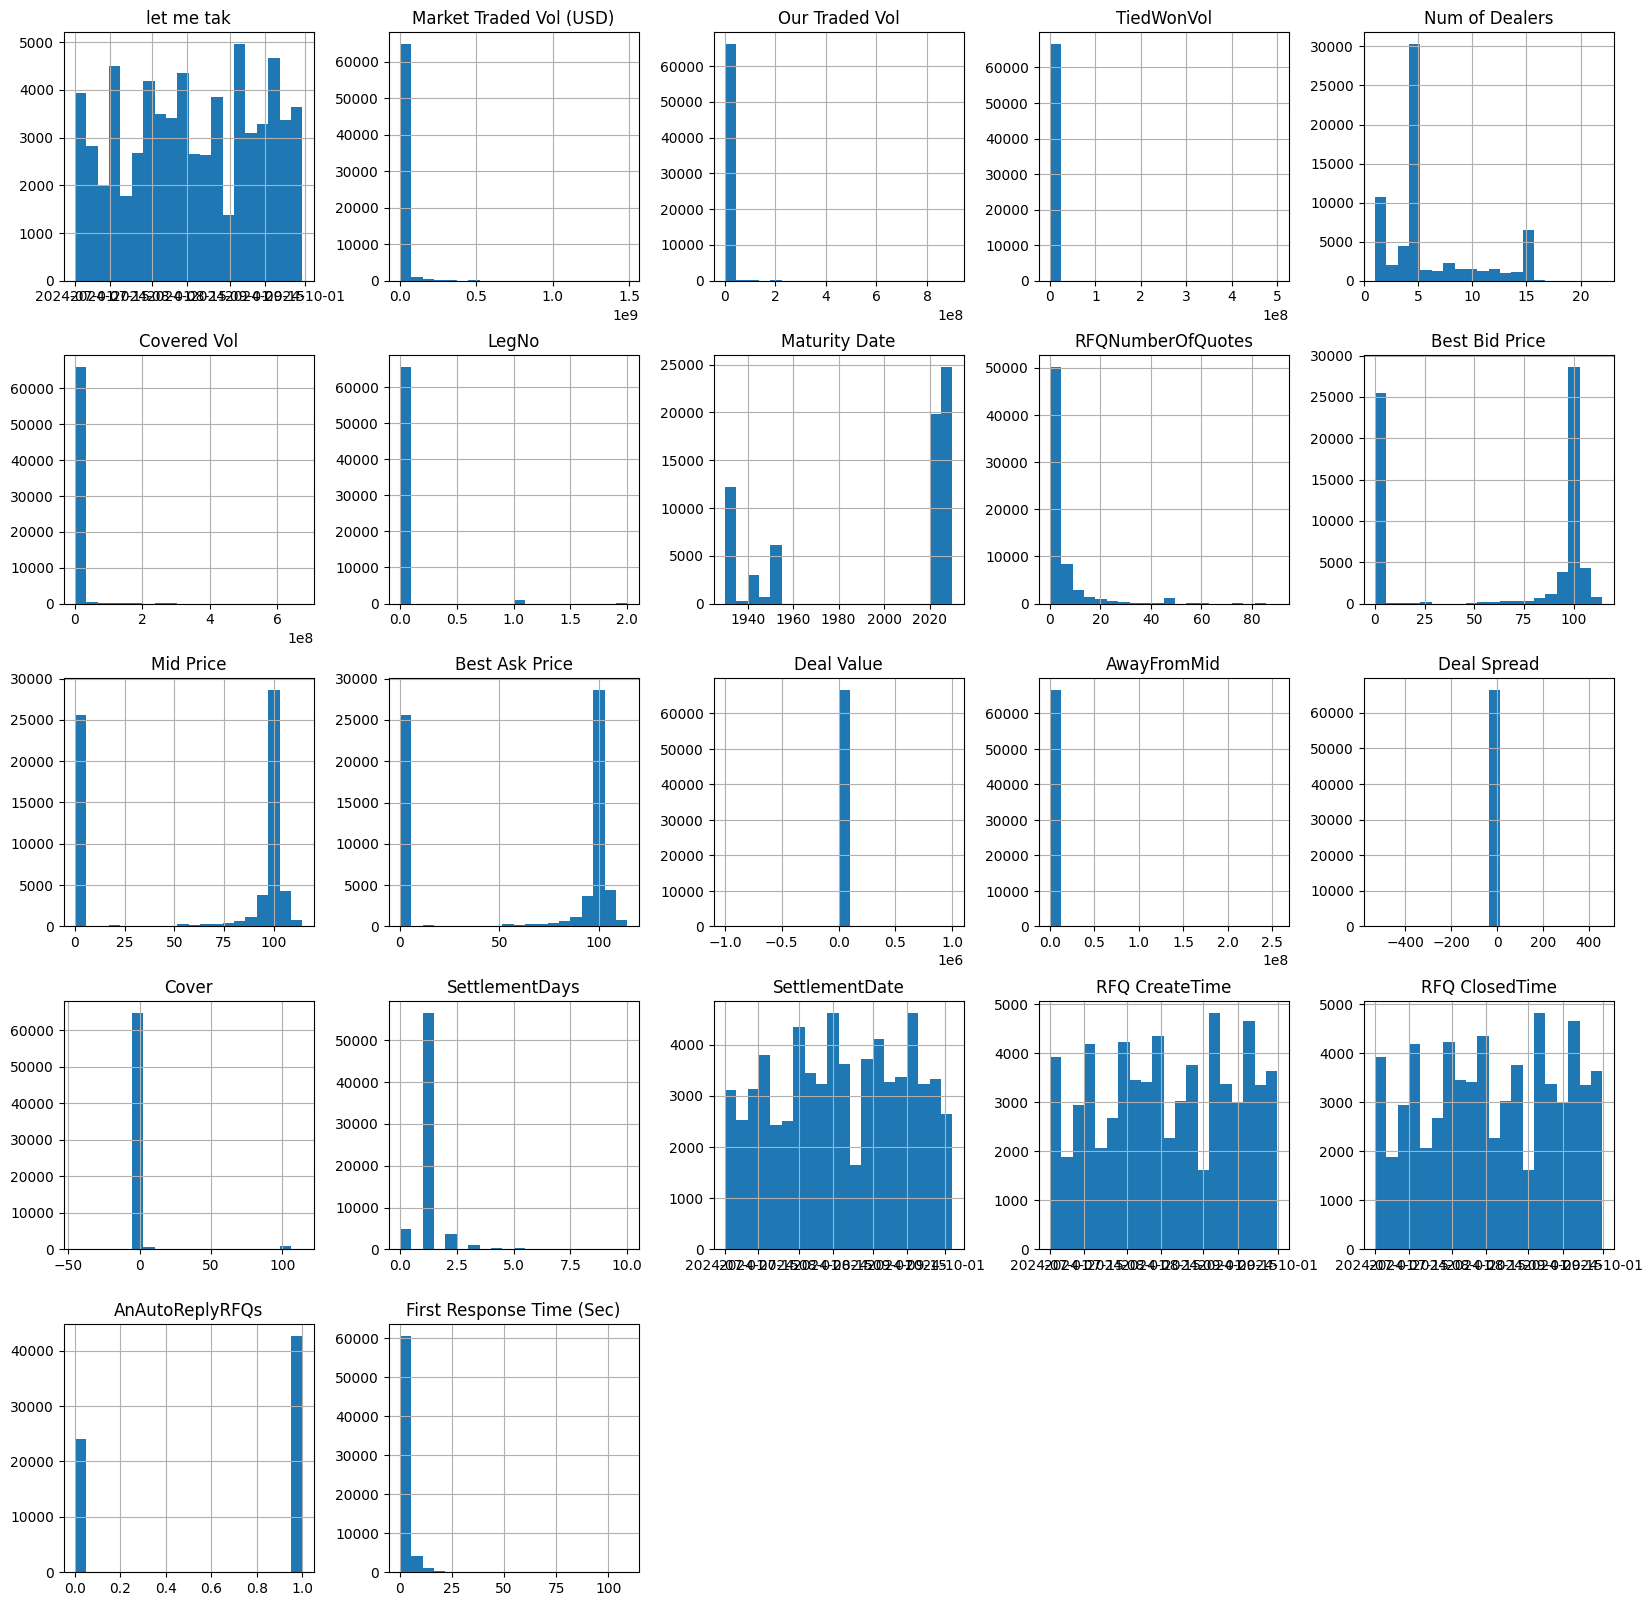

In [7]:
df.hist(bins=20, figsize=(20,20))
plt.show()

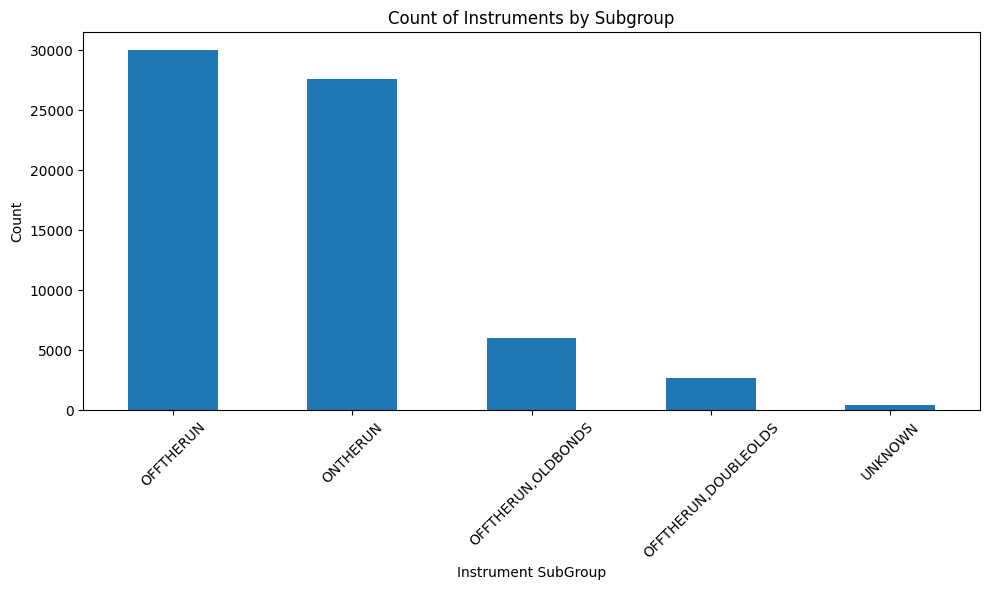

In [8]:
subgroup_counts = df['InstrumentSubGroup'].value_counts()

# Plot the bar chart
plt.figure(figsize=(10, 6))
subgroup_counts.plot(kind='bar')
plt.title('Count of Instruments by Subgroup')
plt.xlabel('Instrument SubGroup')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [9]:
subgroup_counts = df['Maturity Date'].value_counts()
subgroup_counts

,count
Maturity Date,
1934-08-15,4207
1934-05-15,3407
1954-05-15,2244
1954-08-15,1620
2029-07-31,1620
...,...
2025-10-02,3
1935-11-15,2
1935-05-15,1


In [10]:
subgroup_counts = df['MaturityBucket'].value_counts()
subgroup_counts

,count
MaturityBucket,
<18mos,32174
10-30y,11647
7y-10y,8384
3y-5y,7087
5y-7y,2875
18m-2y,2343
2y-3y,2171


In [11]:
subgroup_counts = df['Sector'].value_counts()
subgroup_counts

,count
Sector,
BILLS,23234
7-10 YR,11025
15-30 YR,8678
0-1 YR,7508
5-7 YR,7081
2-3 YR,3700
3-5 YR,2587
TIPS,952
STRIPS,934


In [12]:
subgroup_counts = df['SettlementDate'].value_counts()
subgroup_counts

,count
SettlementDate,
2024-08-15,1864
2024-09-03,1563
2024-08-08,1379
2024-08-06,1376
2024-10-01,1344
...,...
2024-07-29,638
2024-10-02,106
2024-07-01,66


In [13]:
group_30 = df[df['MaturityBucket'] == "10-30y"]
group_30

,let me tak,Id,Client,RFQStatus,InstrumentSubGroup,Market Traded Vol (USD),Our Traded Vol,TiedWonVol,Num of Dealers,Trader,...,SettlementDays,SettlementDate,SettlementStops,RFQ CreateTime,RFQ ClosedTime,AnAutoReplyRFQs,First Response Time (Sec),TradeSizeBucket,Sector,MaturityBucket
15,2024-07-01,66828A5945CC00110006,Client144,CustomerTimeOut,ONTHERUN,0,0,0,15,Trader2,...,1,2024-07-02,T+1,2024-07-01 06:52:00,2024-07-01 06:53:00,1,0.06,500K-1M,15-30 YR,10-30y
16,2024-07-01,66829B2857D000050001,Client131,CustomerTimeOut,ONTHERUN,0,0,0,5,Trader3,...,1,2024-07-02,T+1,2024-07-01 08:04:00,2024-07-01 08:05:00,0,9.20,50+M,15-30 YR,10-30y
23,2024-07-01,66828996E62000090002,Client111,CustomerTimeOut,ONTHERUN,0,0,0,10,Trader1,...,1,2024-07-02,T+1,2024-07-01 06:49:00,2024-07-01 06:50:00,1,0.04,5-10M,15-30 YR,10-30y
25,2024-07-01,6682AA26E05000280004,Client616,CustomerTimeOut,OFFTHERUN,0,0,0,10,Trader2,...,1,2024-07-02,T+1,2024-07-01 09:07:00,2024-07-01 09:09:00,1,0.06,500K-1M,15-30 YR,10-30y
27,2024-07-01,6682B47A57D000780004,Client287,CustomerTimeOut,OFFTHERUN,0,0,0,5,Trader3,...,1,2024-07-02,T+1,2024-07-01 09:52:00,2024-07-01 09:54:00,1,0.03,5-10M,15-30 YR,10-30y
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66610,2024-09-30,E6FAA99157F000340001,Client33,Done,"OFFTHERUN,OLDBONDS",2000000,2000000,0,1,Trader2,...,1,2024-10-01,T+1,2024-09-30 09:37:00,2024-09-30 09:37:00,1,0.05,1-5M,15-30 YR,10-30y
66613,2024-09-30,66FB0911432800250001,Client32,Done,ONTHERUN,1300000,1300000,0,3,Trader2,...,1,2024-10-01,T+1,2024-09-30 16:25:00,2024-09-30 16:25:00,1,0.03,1-5M,15-30 YR,10-30y
66618,2024-09-30,66FACEF3432800120001,Client30,Done,ONTHERUN,1902000,1902000,0,1,Trader2,...,1,2024-10-01,T+1,2024-09-30 12:16:00,2024-09-30 12:16:00,0,0.21,1-5M,15-30 YR,10-30y
66667,2024-09-30,TRSY_20240930_2189,Client7,Done,ONTHERUN,19200000,19200000,0,5,Trader3,...,1,2024-10-01,T+1,2024-09-30 16:07:00,2024-09-30 16:07:00,0,0.00,10-25M,15-30 YR,10-30y


In [26]:
group_30['SIGN'] = group_30['Buy/Sell'].apply(lambda x: 1 if x == 'BUY' else -1)
group_30['SIGNED_VOLUME'] = group_30['Our Traded Vol'] * group_30['SIGN']
group_30

<ipython-input-26-edb81bbe142e>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group_30['SIGN'] = group_30['Buy/Sell'].apply(lambda x: 1 if x == 'BUY' else -1)
<ipython-input-26-edb81bbe142e>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group_30['SIGNED_VOLUME'] = group_30['Our Traded Vol'] * group_30['SIGN']


,let me tak,Id,Client,RFQStatus,InstrumentSubGroup,Market Traded Vol (USD),Our Traded Vol,TiedWonVol,Num of Dealers,Trader,...,SettlementStops,RFQ CreateTime,RFQ ClosedTime,AnAutoReplyRFQs,First Response Time (Sec),TradeSizeBucket,Sector,MaturityBucket,SIGN,SIGNED_VOLUME
15,2024-07-01,66828A5945CC00110006,Client144,CustomerTimeOut,ONTHERUN,0,0,0,15,Trader2,...,T+1,2024-07-01 06:52:00,2024-07-01 06:53:00,1,0.06,500K-1M,15-30 YR,10-30y,-1,0
16,2024-07-01,66829B2857D000050001,Client131,CustomerTimeOut,ONTHERUN,0,0,0,5,Trader3,...,T+1,2024-07-01 08:04:00,2024-07-01 08:05:00,0,9.20,50+M,15-30 YR,10-30y,-1,0
23,2024-07-01,66828996E62000090002,Client111,CustomerTimeOut,ONTHERUN,0,0,0,10,Trader1,...,T+1,2024-07-01 06:49:00,2024-07-01 06:50:00,1,0.04,5-10M,15-30 YR,10-30y,-1,0
25,2024-07-01,6682AA26E05000280004,Client616,CustomerTimeOut,OFFTHERUN,0,0,0,10,Trader2,...,T+1,2024-07-01 09:07:00,2024-07-01 09:09:00,1,0.06,500K-1M,15-30 YR,10-30y,-1,0
27,2024-07-01,6682B47A57D000780004,Client287,CustomerTimeOut,OFFTHERUN,0,0,0,5,Trader3,...,T+1,2024-07-01 09:52:00,2024-07-01 09:54:00,1,0.03,5-10M,15-30 YR,10-30y,-1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66610,2024-09-30,E6FAA99157F000340001,Client33,Done,"OFFTHERUN,OLDBONDS",2000000,2000000,0,1,Trader2,...,T+1,2024-09-30 09:37:00,2024-09-30 09:37:00,1,0.05,1-5M,15-30 YR,10-30y,-1,-2000000
66613,2024-09-30,66FB0911432800250001,Client32,Done,ONTHERUN,1300000,1300000,0,3,Trader2,...,T+1,2024-09-30 16:25:00,2024-09-30 16:25:00,1,0.03,1-5M,15-30 YR,10-30y,-1,-1300000
66618,2024-09-30,66FACEF3432800120001,Client30,Done,ONTHERUN,1902000,1902000,0,1,Trader2,...,T+1,2024-09-30 12:16:00,2024-09-30 12:16:00,0,0.21,1-5M,15-30 YR,10-30y,-1,-1902000
66667,2024-09-30,TRSY_20240930_2189,Client7,Done,ONTHERUN,19200000,19200000,0,5,Trader3,...,T+1,2024-09-30 16:07:00,2024-09-30 16:07:00,0,0.00,10-25M,15-30 YR,10-30y,-1,-19200000


In [30]:
group_30.columns

Index(['let me tak', 'Id', 'Client', 'RFQStatus', 'InstrumentSubGroup',
       'Market Traded Vol (USD)', 'Our Traded Vol', 'TiedWonVol',
       'Num of Dealers', 'Trader', 'Sales', 'Covered Vol', 'ActionStr', 'Tier',
       'InstrumentCode', 'InstrumentDescription', 'AssetClass', 'Market',
       'LegNo', 'Maturity Date', 'RFQNumberOfQuotes', 'Buy/Sell',
       'Best Bid Price', 'Mid Price', 'Best Ask Price', 'Deal Value',
       'AwayFromMid', 'TickIdentifier', 'Deal Spread', 'Cover', 'CoverPnL',
       'SettlementDays', 'SettlementDate', 'SettlementStops', 'RFQ CreateTime',
       'RFQ ClosedTime', 'AnAutoReplyRFQs', 'First Response Time (Sec)',
       'TradeSizeBucket', 'Sector', 'MaturityBucket', 'SIGN', 'SIGNED_VOLUME'],
      dtype='object')

In [32]:
group_30['EventDate'] = pd.to_datetime(group_30['SettlementDate'])

# Group by 'TRADEDATE' and calculate the daily volatility as the standard deviation of 'PRICE'
daily_volatility = group_30.groupby('EventDate')['Mid Price'].std()

# Map the daily volatility back to the original DataFrame
group_30['Daily_Volatility'] = group_30['EventDate'].map(daily_volatility)
group_30['Daily_Volatility']

<ipython-input-32-2b75312ce8d1>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group_30['EventDate'] = pd.to_datetime(group_30['SettlementDate'])
<ipython-input-32-2b75312ce8d1>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group_30['Daily_Volatility'] = group_30['EventDate'].map(daily_volatility)


,Daily_Volatility
15,21.456496
16,21.456496
23,21.456496
25,21.456496
27,21.456496
...,...
66610,40.771984
66613,40.771984
66618,40.771984
66667,40.771984


In [33]:
# Step 1: Inspect the column
print(group_30['EventDate'].head())  # Check the first few entries to see any irregularities

# Step 2: Remove any extraneous whitespace or convert to string if necessary
group_30['EventDate'] = group_30['EventDate'].astype(str).str.strip()

# Step 3: Convert 'EventDate' to datetime, handling errors gracefully
group_30['EventDate'] = pd.to_datetime(group_30['EventDate'], errors='coerce')

# Step 4: Check for any NaT (missing dates after conversion)
print("Missing dates after conversion:", group_30['EventDate'].isna().sum())

# Step 5: Proceed with filtering after confirming successful conversion
group_30_july = group_30[group_30['EventDate'] < '2024-08-01']

adv = group_30_july['Market Traded Vol (USD)'].cumsum()

group_30_july['ADV'] = adv.iloc[-1] / len(group_30_july)

group_30_july['ADV']

15   2024-07-02
16   2024-07-02
23   2024-07-02
25   2024-07-02
27   2024-07-02
Name: EventDate, dtype: datetime64[ns]
Missing dates after conversion: 0


<ipython-input-33-8dbeb79f3ef8>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group_30['EventDate'] = group_30['EventDate'].astype(str).str.strip()
<ipython-input-33-8dbeb79f3ef8>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group_30['EventDate'] = pd.to_datetime(group_30['EventDate'], errors='coerce')
<ipython-input-33-8dbeb79f3ef8>:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats 

,ADV
15,3.397085e+06
16,3.397085e+06
23,3.397085e+06
25,3.397085e+06
27,3.397085e+06
...,...
19335,3.397085e+06
19391,3.397085e+06
19853,3.397085e+06
19857,3.397085e+06


In [34]:
import numpy as np
import math
from sklearn.linear_model import LinearRegression

def calculate_impact_and_liquidity(data, h_minutes, delta_t=1/24):  # h in minutes, delta_t still in hours
    """
    Calculate impact state I_t and market activity v_t using half-life transformation
    h_minutes: time interval for return horizon (in minutes)
    delta_t: time step for impact decay (in hours)
    """
    data = data.copy()
    data['ABS_VOLUME'] = data['SIGNED_VOLUME'].abs()

    # Convert h from minutes to hours for beta calculation
    h_hours = h_minutes / 60

    # Calculate beta using half-life transformation
    beta = math.log(2) / h_hours

    # Initialize arrays for impact (I_t) and liquidity (v_t)
    I_values = np.zeros(len(data))
    v_values = np.zeros(len(data))

    # Initial values
    I_values[0] = data['Daily_Volatility'].iloc[0] * data['SIGNED_VOLUME'].iloc[0] / np.sqrt(data['ADV'].iloc[0])
    v_values[0] = data['ABS_VOLUME'].iloc[0]

    # Exponential moving average with same half-life
    decay_factor = np.exp(-beta * delta_t)  # Using delta_t for decay

    # Iterate over time steps
    for i in range(1, len(data)):
        sigma = data['Daily_Volatility'].iloc[i]
        qt = data['SIGNED_VOLUME'].iloc[i]
        adv = data['ADV'].iloc[i]

        # Update market activity using exponential moving average
        v_values[i] = decay_factor * v_values[i-1] + (1 - decay_factor) * abs(qt)

        # Calculate impact state with flow effects and impact decay
        if adv != 0 and v_values[i] != 0:
            I_values[i] = I_values[i-1] * (1 - beta * delta_t)  # Using delta_t for decay
            I_values[i] += sigma * (qt / np.sqrt(adv * v_values[i]))  # Flow effects
        else:
            I_values[i] = I_values[i-1]

    data['I_t'] = I_values
    data['v_t'] = v_values
    return data, beta

def estimate_lambda(data, initial_lambda, h_minutes, delta_t=1/24):
    """
    Estimate optimal lambda for a given time interval h_minutes
    h_minutes: horizon for returns (in minutes)
    delta_t: time step for impact decay (in hours)
    """
    # Calculate impact states
    impact_data, beta = calculate_impact_and_liquidity(data, h_minutes, delta_t)

    # Calculate returns using h periods
    h_periods = int(len(impact_data) * (h_minutes/(24*60)))  # Convert minutes to fraction of day
    h_periods = max(1, h_periods)  # Ensure at least 1 period

    # Calculate Δ^h P = (P_{t+h} - P_t)/P_t using h as the horizon
    impact_data['Delta_h_P'] = (impact_data['Mid Price'].shift(-h_periods) - impact_data['Mid Price']) / impact_data['Mid Price']

    # Calculate Δ^h I = I_{t+h} - I_t using h as the horizon
    impact_data['Delta_h_I'] = impact_data['I_t'].shift(-h_periods) - impact_data['I_t']

    # Remove NaN values
    impact_data.dropna(inplace=True)

    # Run regression: Δ^h P = Δ^h I(λ) + ϵ
    X = impact_data[['Delta_h_I']]
    y = impact_data['Delta_h_P']

    # Remove or replace infinite values in y
    if np.isinf(y).any() or np.isnan(y).any():
        # print("Found infinite or NaN values in y. Replacing them.")
        y = np.where(np.isinf(y), np.nan, y)  # Replace inf with NaN for easy handling
        y = np.nan_to_num(y, nan=np.nanmean(y))  # Replace NaN with column mean or remove these rows

    # Similarly, handle X if needed
    X = np.array(X)
    if np.isinf(X).any() or np.isnan(X).any():
        # print("Found infinite or NaN values in X. Replacing them.")
        X = np.where(np.isinf(X), np.nan, X)
        X = np.nan_to_num(X, nan=np.nanmean(X))

    model = LinearRegression()
    model.fit(X, y)

    optimal_lambda = model.coef_[0]
    r_squared = model.score(X, y)

    return optimal_lambda, r_squared, beta, impact_data

def grid_search_lambda(data, h_values_minutes, delta_t=1/24):
    """
    Test different time intervals to find optimal lambda
    """
    results = []
    for h_minutes in h_values_minutes:
        optimal_lambda, r_squared, beta, _ = estimate_lambda(data, 1.0, h_minutes, delta_t)
        results.append({
            'h_minutes': h_minutes,
            'h_hours': h_minutes/60,
            'h_periods': max(1, int(len(data) * (h_minutes/(24*60)))),
            'beta': beta,
            'lambda': optimal_lambda,
            'r_squared': r_squared
        })
    return results

In [35]:
h_values_minutes = [6, 12, 18, 24, 30, 48, 60, 90, 120]  # horizons in minutes
delta_t = 1/24  # 1 hour for impact decay
results = grid_search_lambda(group_30_july, h_values_minutes, delta_t)

def print_results(results):
    print("\nSummary of Results:")
    print("-" * 80)
    print(f"{'h (min)':>10} {'beta':>12} {'lambda':>12} {'R²':>12}")
    print("-" * 80)

    for result in results:
        h_min = result['h_minutes']
        beta = result['beta']
        lambda_val = result['lambda']
        r2 = result['r_squared']

        print(f"{h_min:10.1f} {beta:12.6f} {lambda_val:12.6f} {r2:12.6f}")
    print("-" * 80)

# After running grid_search_lambda, use:
group_30_july = group_30_july.dropna()
results = grid_search_lambda(group_30_july, h_values_minutes, delta_t)
print_results(results)


Summary of Results:
--------------------------------------------------------------------------------
   h (min)         beta       lambda           R²
--------------------------------------------------------------------------------
       6.0     6.931472    -0.013323     0.014533
      12.0     3.465736    -0.002600     0.002357
      18.0     2.310491    -0.001050     0.000873
      24.0     1.732868    -0.000579     0.000491
      30.0     1.386294    -0.000730     0.001178
      48.0     0.866434    -0.001217     0.006968
      60.0     0.693147    -0.001618     0.014310
      90.0     0.462098    -0.000535     0.002433
     120.0     0.346574    -0.000327     0.001827
--------------------------------------------------------------------------------


In [36]:
import math

In [37]:
def It(data, h_minutes, delta_t=1/24):  # h in minutes, delta_t still in hours
    """
    Calculate impact state I_t and market activity v_t using half-life transformation
    h_minutes: time interval for return horizon (in minutes)
    delta_t: time step for impact decay (in hours)
    """
    data = data.copy()
    data['ABS_VOLUME'] = data['SIGNED_VOLUME'].abs()

    # Convert h from minutes to hours for beta calculation
    h_hours = h_minutes / 60

    # Calculate beta using half-life transformation
    beta = math.log(2) / h_hours

    # Initialize arrays for impact (I_t) and liquidity (v_t)
    I_values = np.zeros(len(data))
    v_values = np.zeros(len(data))

    # Initial values
    I_values[0] = data['Daily_Volatility'].iloc[0] * data['SIGNED_VOLUME'].iloc[0] / np.sqrt(data['ADV'].iloc[0])
    v_values[0] = data['ABS_VOLUME'].iloc[0]

    # Exponential moving average with same half-life
    decay_factor = np.exp(-beta * delta_t)  # Using delta_t for decay

    # Iterate over time steps
    for i in range(1, len(data)):
        sigma = data['Daily_Volatility'].iloc[i]
        qt = data['SIGNED_VOLUME'].iloc[i]
        adv = data['ADV'].iloc[i]

        # Update market activity using exponential moving average
        v_values[i] = decay_factor * v_values[i-1] + (1 - decay_factor) * abs(qt)

        # Calculate impact state with flow effects and impact decay
        if adv != 0 and v_values[i] != 0:
            I_values[i] = I_values[i-1] * (1 - beta * delta_t)  # Using delta_t for decay
            I_values[i] += sigma * (qt / np.sqrt(adv * v_values[i]))  # Flow effects
        else:
            I_values[i] = I_values[i-1]

    data['I_t'] = I_values
    data['v_t'] = v_values
    return data


In [38]:
df_it = It(group_30_july, h_minutes=120, delta_t=1/24)

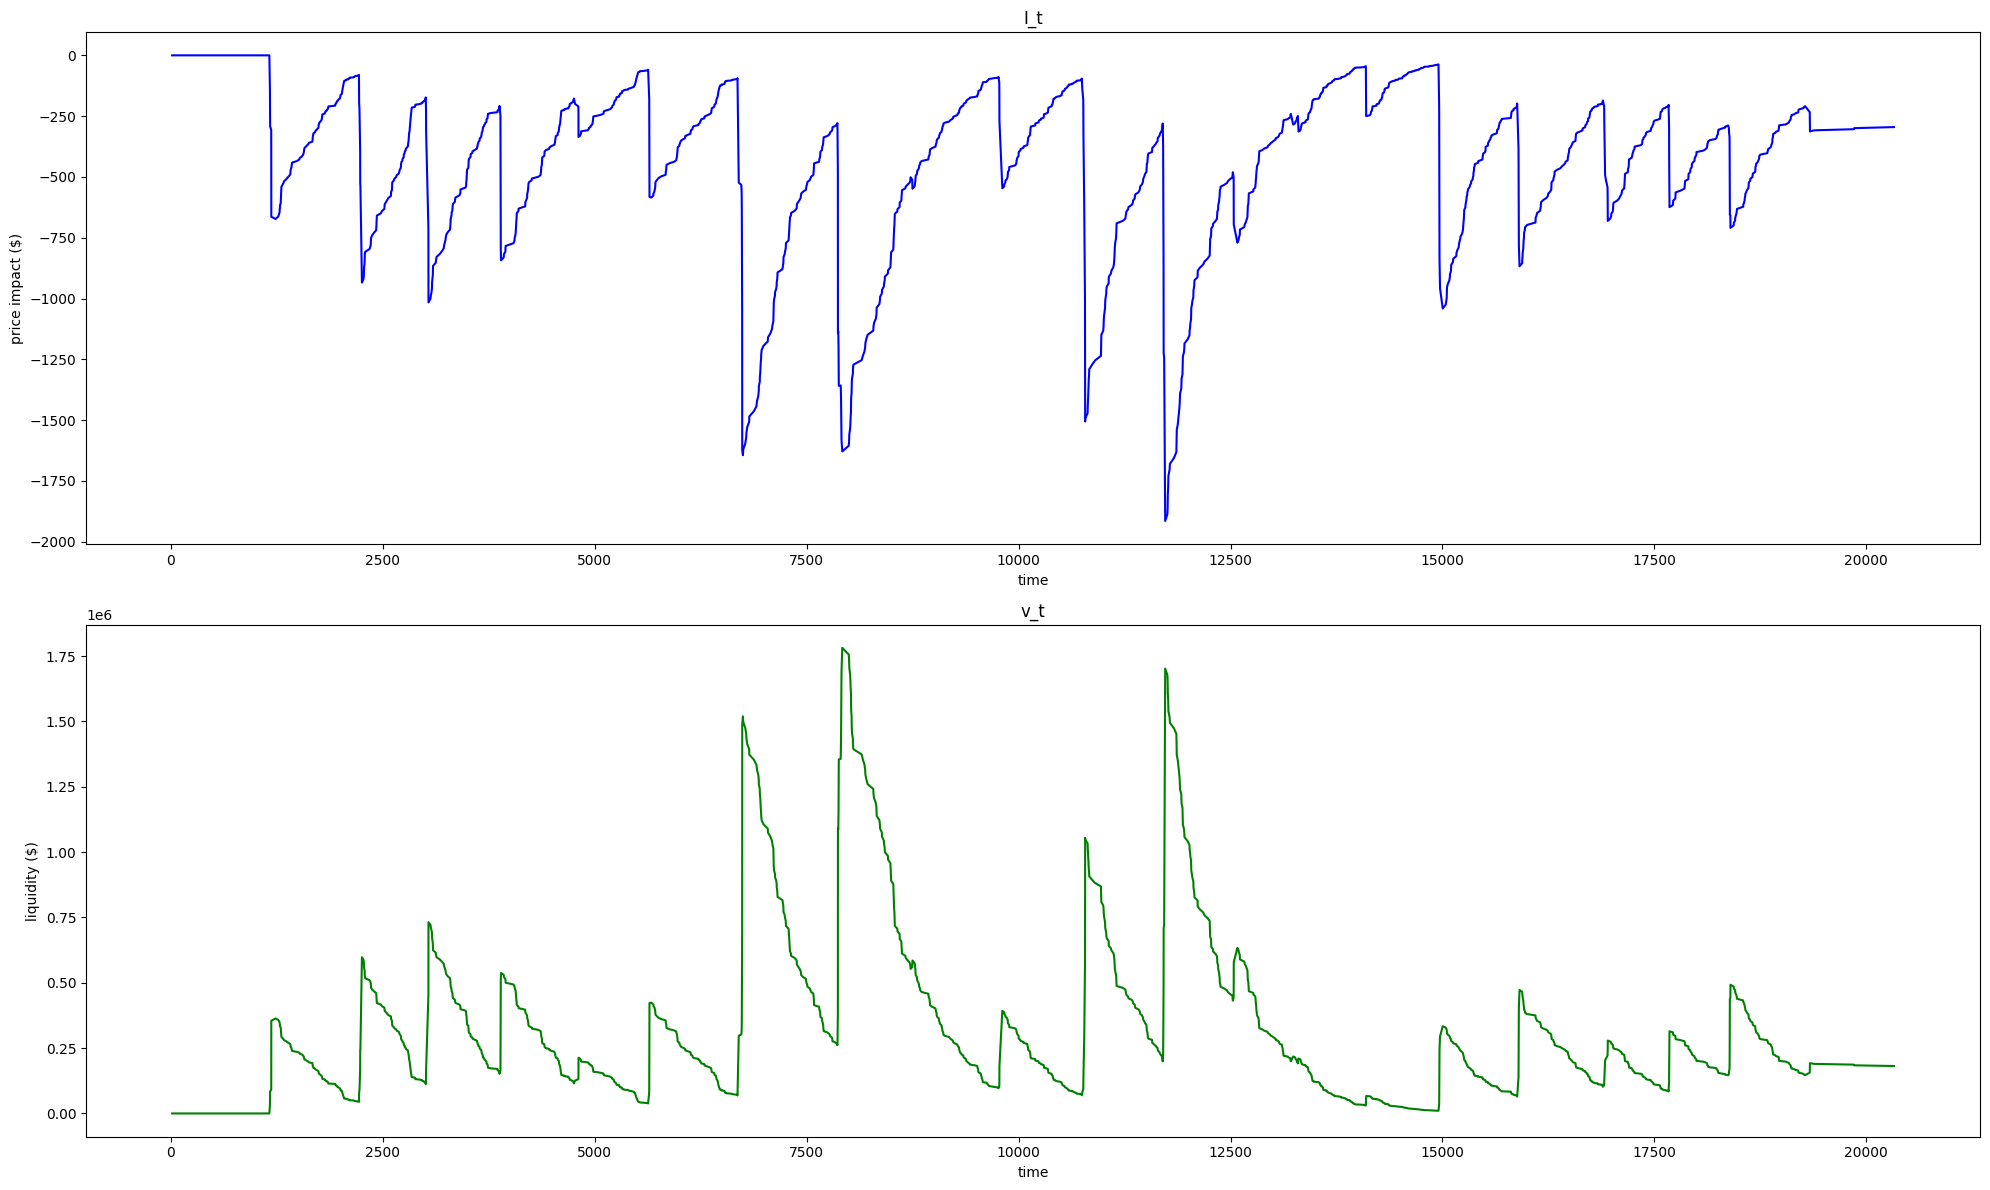

In [39]:
plt.figure(figsize=(20, 12))

# First subplot for df_it.I_t
plt.subplot(2, 1, 1)
plt.plot(df_it.I_t, color='blue')
plt.xlabel('time')
plt.ylabel('price impact ($)')
plt.title('I_t')

# Second subplot for df_it.v_t
plt.subplot(2, 1, 2)
plt.plot(df_it.v_t, color='green')
plt.xlabel('time')
plt.ylabel('liquidity ($)')
plt.title('v_t')

plt.tight_layout()
plt.show()


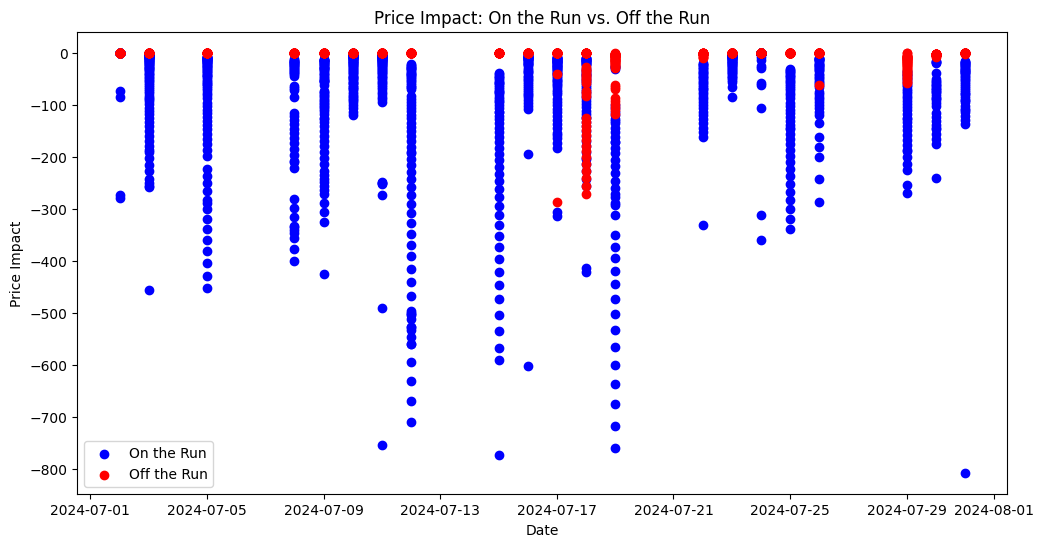

In [45]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# Sample data structure and separation
on_the_run_data = group_30_july[group_30_july['InstrumentSubGroup'] == 'ONTHERUN']
off_the_run_data = group_30_july[group_30_july['InstrumentSubGroup'] == 'OFFTHERUN']

def calculate_price_impact(data, h_minutes, delta_t=1/24):
    """
    Calculate impact state I_t and market activity v_t for price impact.
    """
    data = data.copy()
    data['ABS_VOLUME'] = data['SIGNED_VOLUME'].abs()

    h_hours = h_minutes / 60
    beta = np.log(2) / h_hours
    I_values = np.zeros(len(data))
    v_values = np.zeros(len(data))

    I_values[0] = data['Daily_Volatility'].iloc[0] * data['SIGNED_VOLUME'].iloc[0] / np.sqrt(data['ADV'].iloc[0])
    v_values[0] = data['ABS_VOLUME'].iloc[0]

    decay_factor = np.exp(-beta * delta_t)

    for i in range(1, len(data)):
        sigma = data['Daily_Volatility'].iloc[i]
        qt = data['SIGNED_VOLUME'].iloc[i]
        adv = data['ADV'].iloc[i]

        v_values[i] = decay_factor * v_values[i-1] + (1 - decay_factor) * abs(qt)

        if adv != 0 and v_values[i] != 0:
            I_values[i] = I_values[i-1] * (1 - beta * delta_t)
            I_values[i] += sigma * (qt / np.sqrt(adv * v_values[i]))
        else:
            I_values[i] = I_values[i-1]

    data['Price_Impact'] = I_values
    return data

# Calculate price impact for on-the-run and off-the-run data
on_the_run_impact = calculate_price_impact(on_the_run_data, h_minutes=30)
off_the_run_impact = calculate_price_impact(off_the_run_data, h_minutes=30)

# Plot the results
plt.figure(figsize=(12, 6))
plt.scatter(on_the_run_impact['EventDate'], on_the_run_impact['Price_Impact'], label='On the Run', color='blue')
plt.scatter(off_the_run_impact['EventDate'], off_the_run_impact['Price_Impact'], label='Off the Run', color='red')

plt.title('Price Impact: On the Run vs. Off the Run')
plt.xlabel('Date')
plt.ylabel('Price Impact')
plt.legend()
plt.show()
